---
## Phase 1: Data Loading & Initial Setup

In [30]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [31]:
# Load California Housing Dataset
california_housing = fetch_california_housing(as_frame=True)

# Extract features and target
X = california_housing.data  # Features
y = california_housing.target  # Target variable (Median House Value)

# Create a complete dataframe
df = california_housing.frame

print("✅ Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

✅ Dataset loaded successfully!

Dataset Shape: (20640, 9)
Features: 8
Samples: 20640


---
## Phase 2: Exploratory Data Analysis (EDA)

### 2.1 Basic Data Inspection

In [32]:
# Display first few rows
print("=" * 80)
print("FIRST 5 ROWS OF DATASET")
print("=" * 80)
display(df.head())

FIRST 5 ROWS OF DATASET


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [33]:
# Dataset information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(df.info())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [34]:
# Statistical summary
print("=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
display(df.describe())

STATISTICAL SUMMARY


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [35]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal Missing Values: {missing_values.sum()}")

MISSING VALUES CHECK
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total Missing Values: 0


In [36]:
# Check for duplicates
print("=" * 80)
print("DUPLICATE VALUES CHECK")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

DUPLICATE VALUES CHECK
Number of duplicate rows: 0


In [37]:
# Feature descriptions
print("=" * 80)
print("FEATURE DESCRIPTIONS")
print("=" * 80)
print(california_housing.DESCR)

FEATURE DESCRIPTIONS
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census,

### 2.2 Statistical Analysis

In [38]:
# Advanced statistical analysis
print("=" * 80)
print("ADVANCED STATISTICS (Skewness & Kurtosis)")
print("=" * 80)

stats_df = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Std Dev': df.std(),
    'Skewness': df.skew(),
    'Kurtosis': df.kurtosis()
})

display(stats_df)

ADVANCED STATISTICS (Skewness & Kurtosis)


,Mean,Median,Std Dev,Skewness,Kurtosis
MedInc,3.870671,3.534800,1.899822,1.646657,4.952524
HouseAge,28.639486,29.000000,12.585558,0.060331,-0.800629
AveRooms,5.429000,5.229129,2.474173,20.697869,879.353264
AveBedrms,1.096675,1.048780,0.473911,31.316956,1636.711972
Population,1425.476744,1166.000000,1132.462122,4.935858,73.553116
AveOccup,3.070655,2.818116,10.386050,97.639561,10651.010636
Latitude,35.631861,34.260000,2.135952,0.465953,-1.117760
Longitude,-119.569704,-118.490000,2.003532,-0.297801,-1.330152
MedHouseVal,2.068558,1.797000,1.153956,0.977763,0.327870


### 2.3 Data Visualization

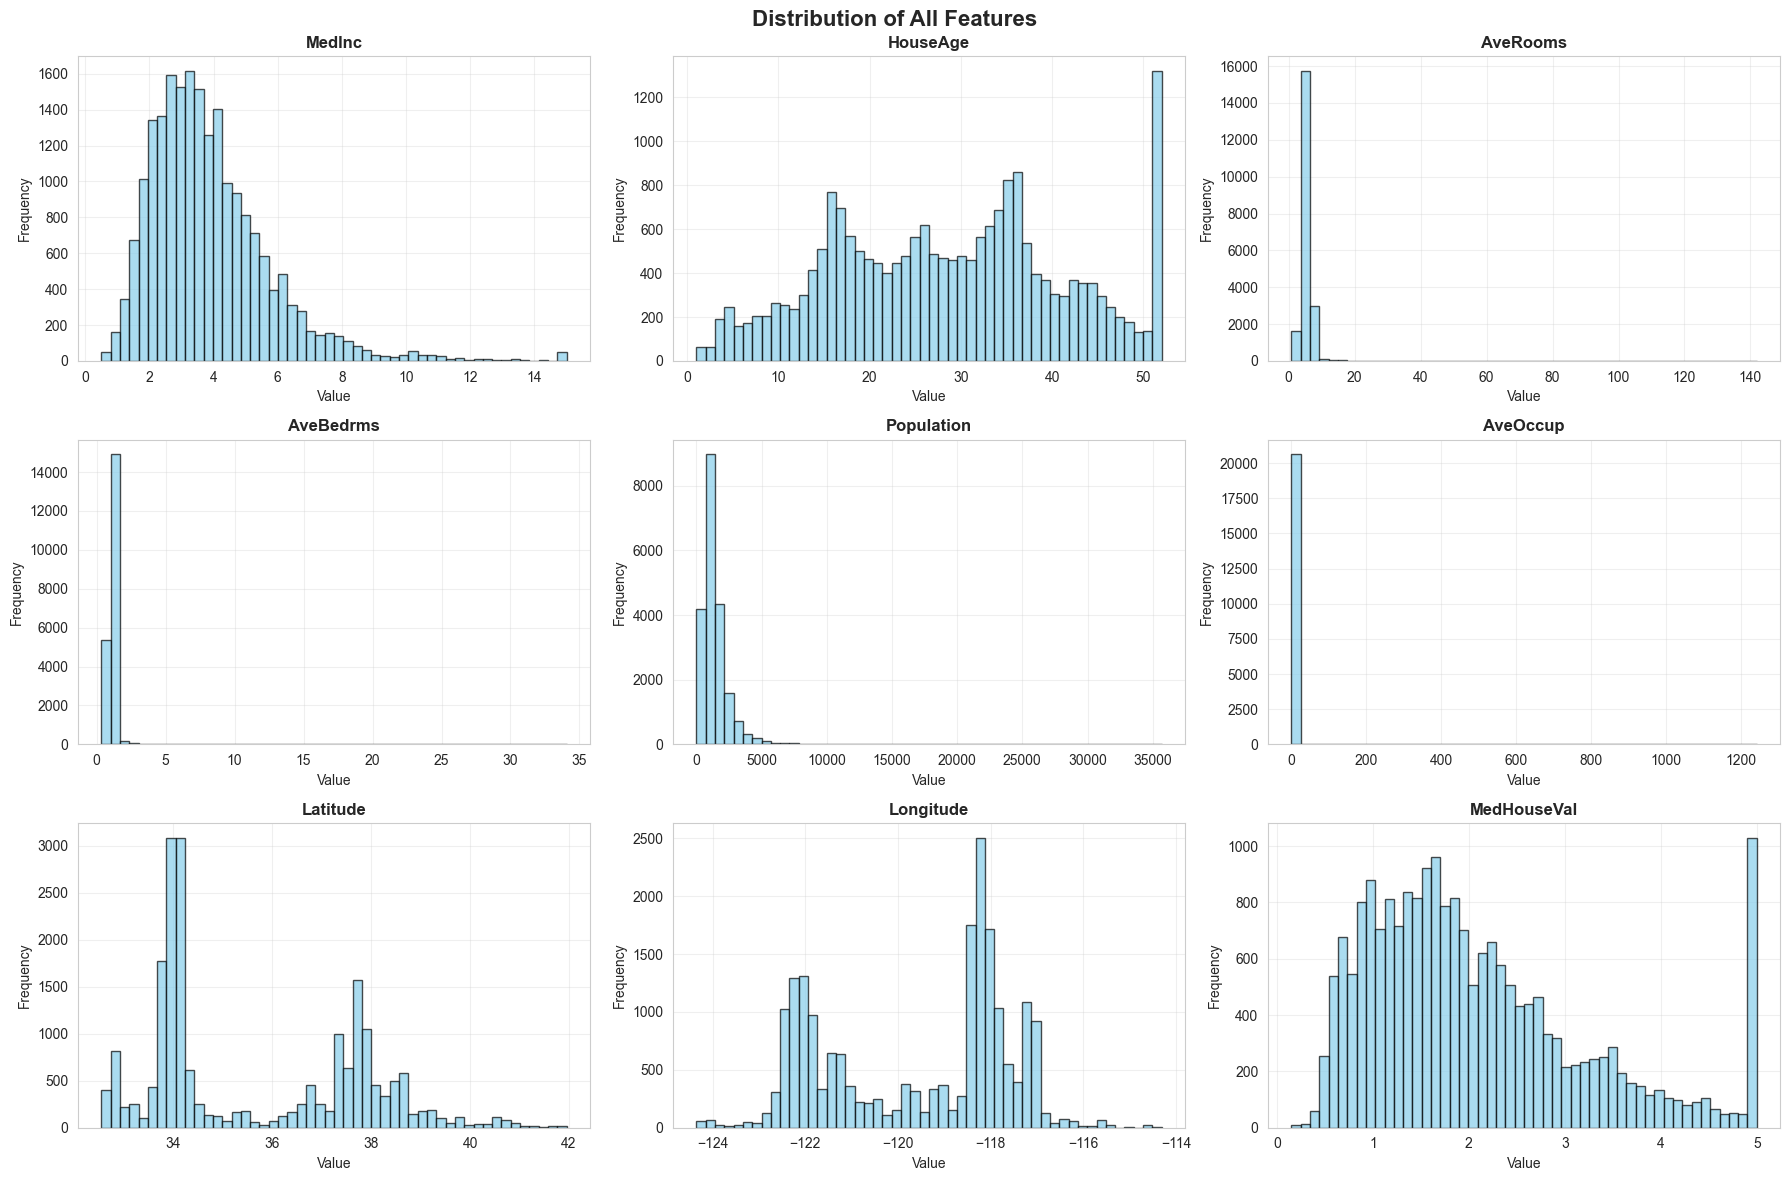

In [39]:
# Distribution of all features (Histograms)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[row, col_idx].set_title(f'{col}', fontweight='bold')
    axes[row, col_idx].set_xlabel('Value')
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

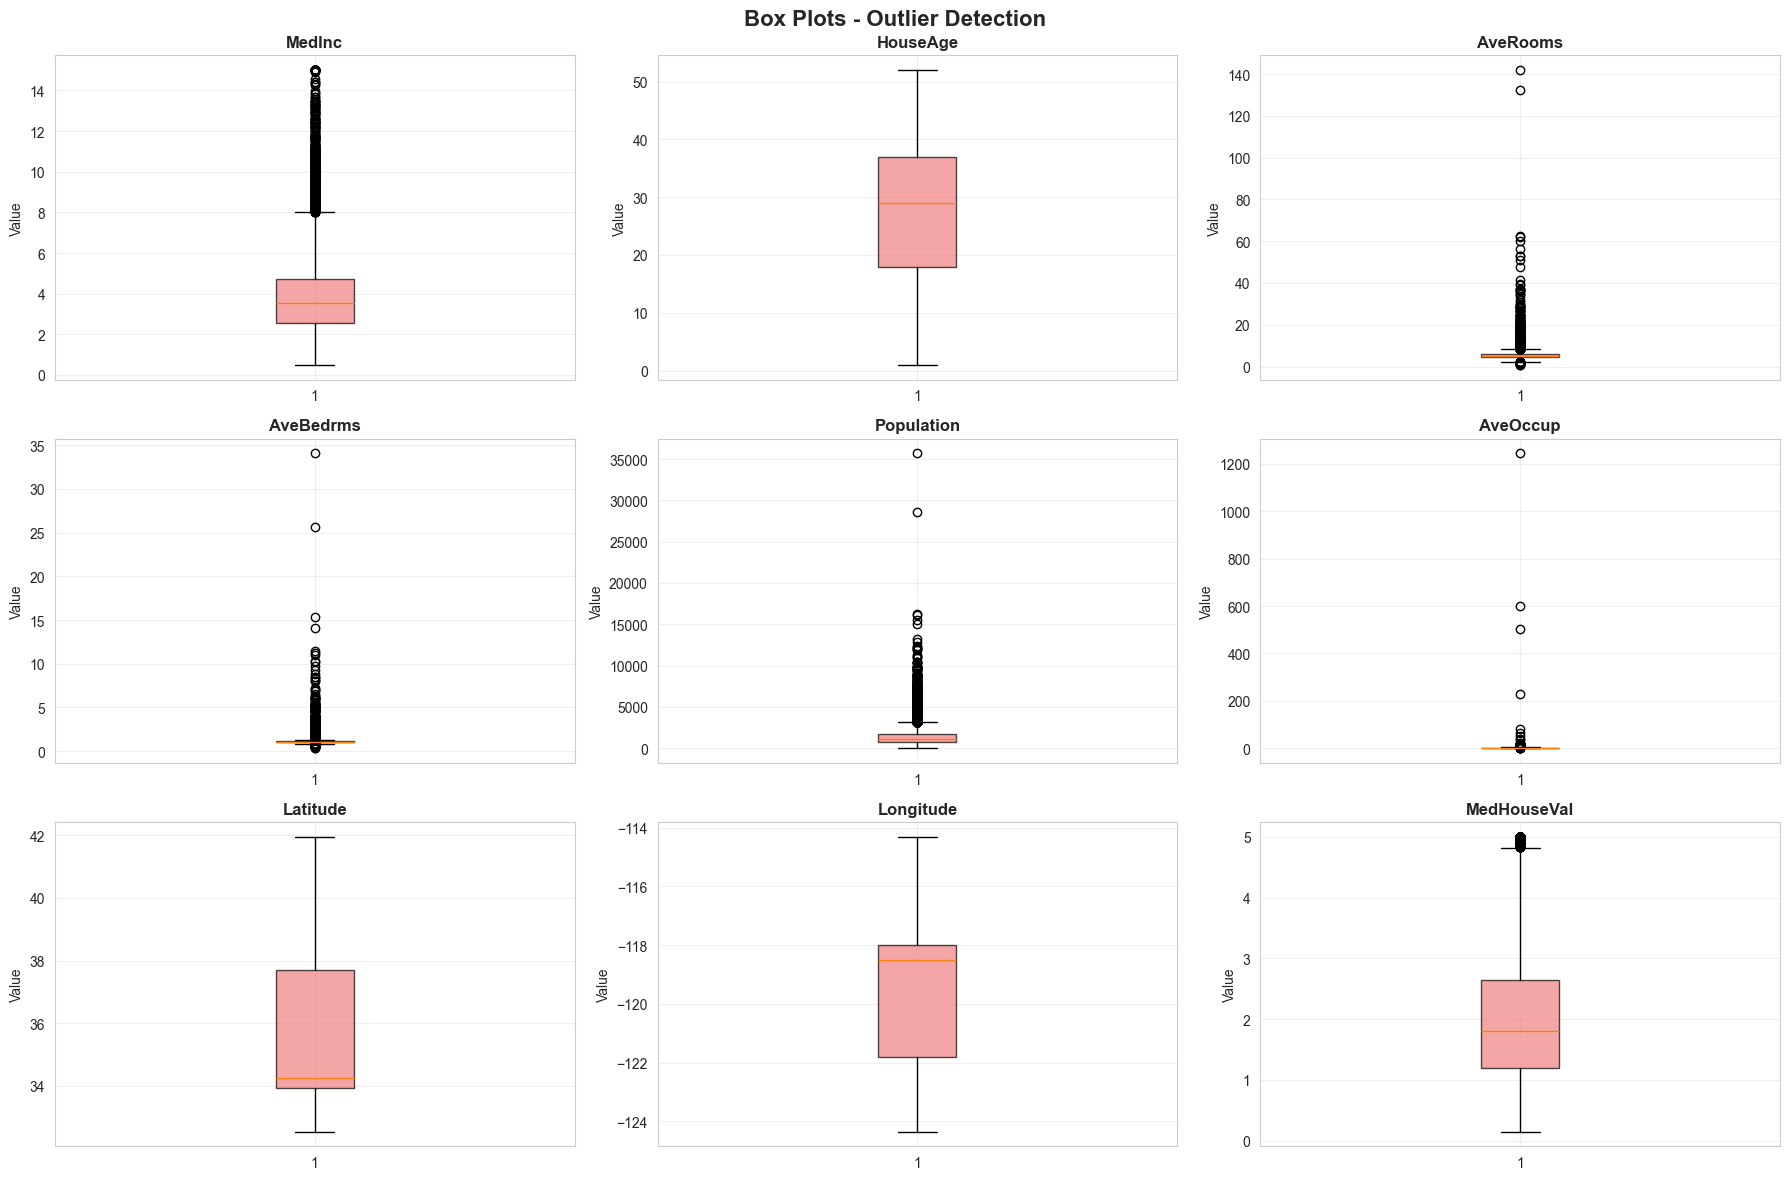

In [40]:
# Box plots to detect outliers
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(df[col], vert=True, patch_artist=True,
                                boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[row, col_idx].set_title(f'{col}', fontweight='bold')
    axes[row, col_idx].set_ylabel('Value')
    axes[row, col_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

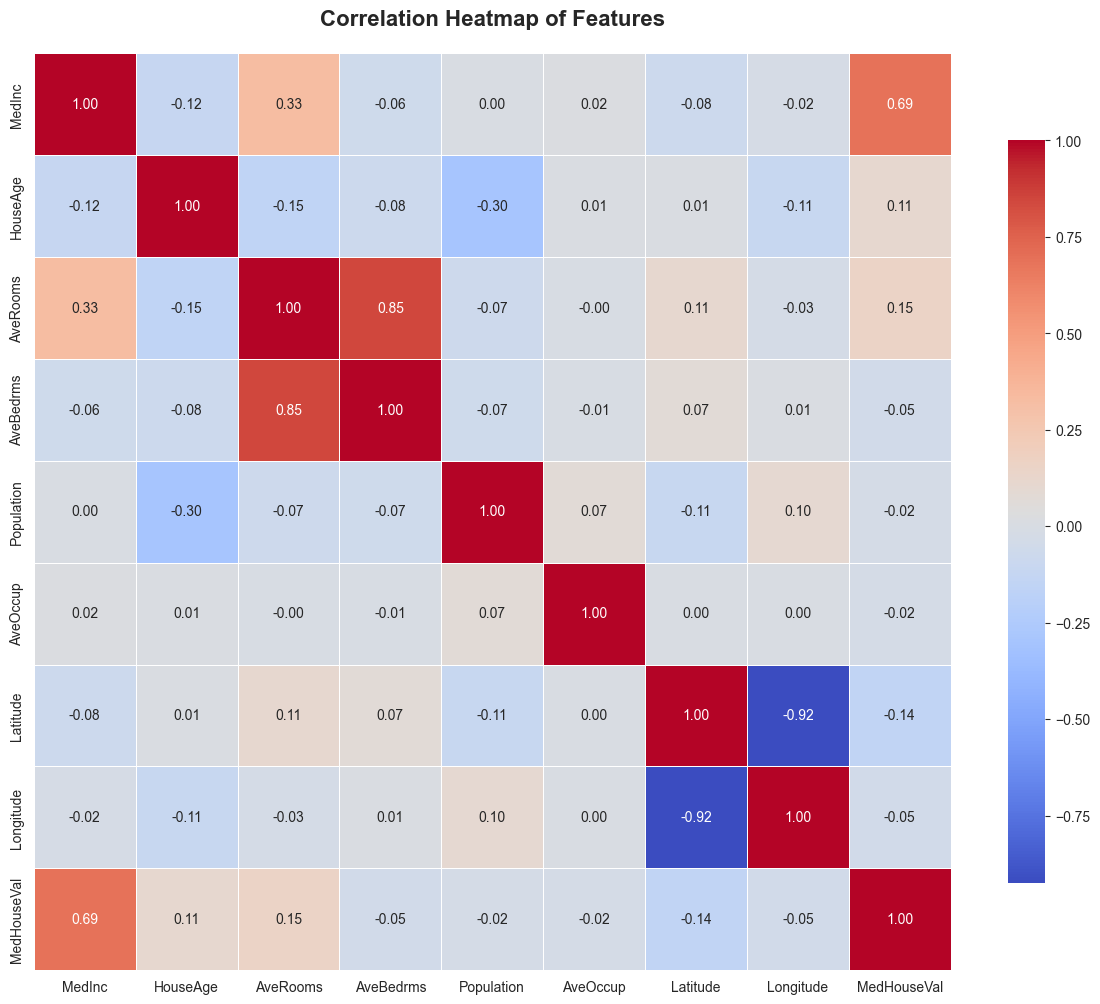


Correlation with Target (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [41]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print top correlations with target
print("\nCorrelation with Target (MedHouseVal):")
target_corr = correlation_matrix['MedHouseVal'].sort_values(ascending=False)
print(target_corr)

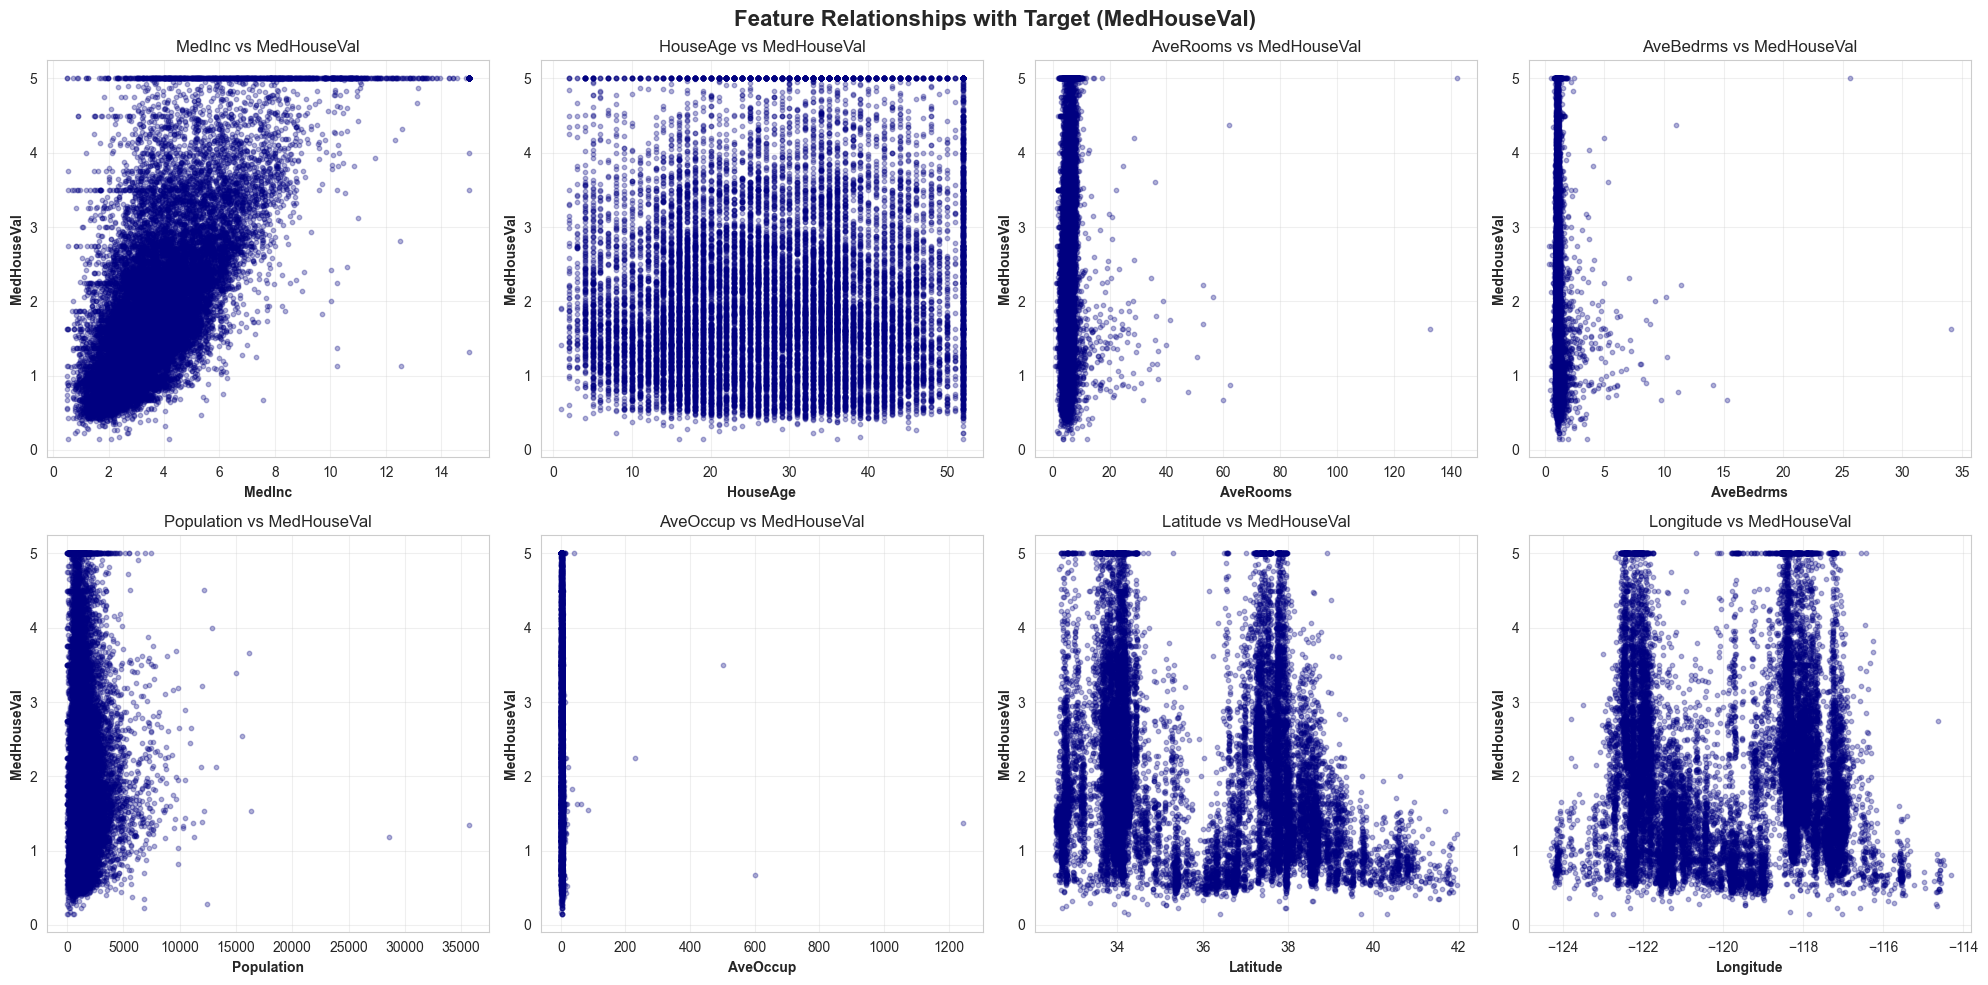

In [42]:
# Scatter plots: Features vs Target
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Feature Relationships with Target (MedHouseVal)', fontsize=16, fontweight='bold')

feature_cols = [col for col in df.columns if col != 'MedHouseVal']

for idx, col in enumerate(feature_cols):
    row = idx // 4
    col_idx = idx % 4
    axes[row, col_idx].scatter(df[col], df['MedHouseVal'], alpha=0.3, s=10, color='navy')
    axes[row, col_idx].set_xlabel(col, fontweight='bold')
    axes[row, col_idx].set_ylabel('MedHouseVal', fontweight='bold')
    axes[row, col_idx].set_title(f'{col} vs MedHouseVal')
    axes[row, col_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Creating pair plot with sample data (5000 samples)...


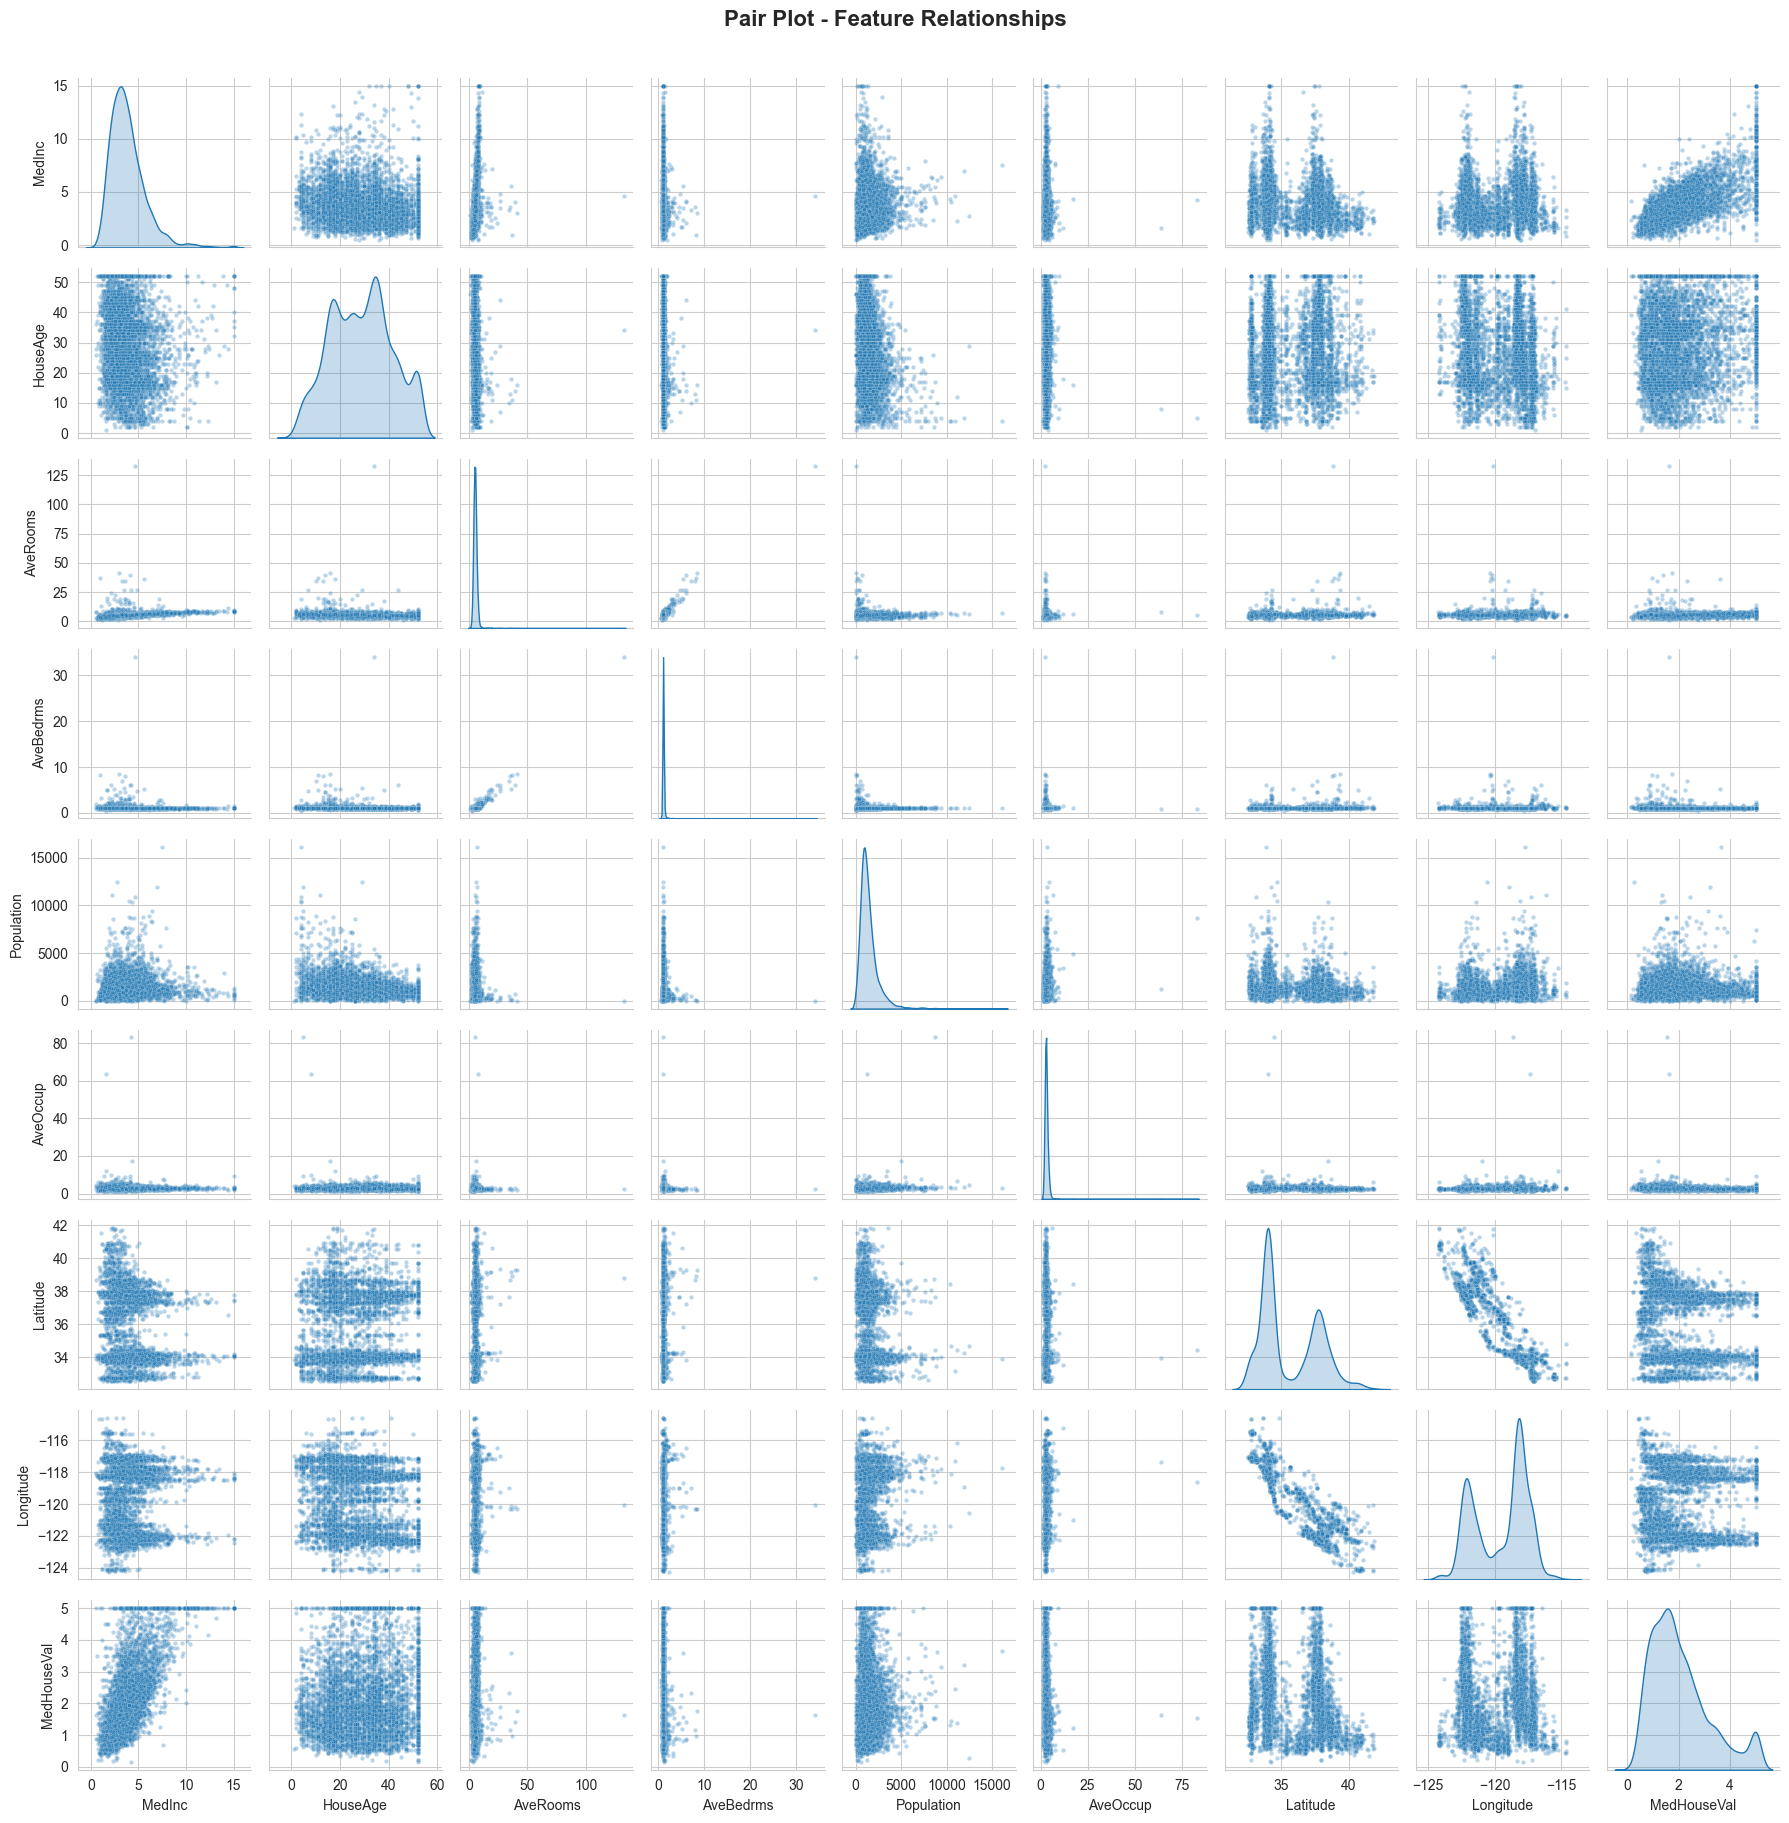

In [14]:
# Pair plot (sample data for performance)
print("Creating pair plot with sample data (5000 samples)...")
sample_df = df.sample(n=5000, random_state=42)
sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10}, height=2)
plt.suptitle('Pair Plot - Feature Relationships', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 3: Data Preprocessing

### 3.1 Train-Test Split

In [15]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nFeatures: {X_train.shape[1]}")

TRAIN-TEST SPLIT
Training set size: 16512 samples (80.0%)
Testing set size: 4128 samples (20.0%)

Features: 8


### 3.2 Feature Scaling

In [16]:
# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 80)
print("FEATURE SCALING")
print("=" * 80)
print("✅ Features scaled using StandardScaler")
print(f"\nOriginal Training Data Shape: {X_train.shape}")
print(f"Scaled Training Data Shape: {X_train_scaled.shape}")

# Show scaling statistics
print("\nScaling Statistics (mean should be ~0, std should be ~1):")
print(f"Mean of scaled training data: {X_train_scaled.mean():.6f}")
print(f"Std of scaled training data: {X_train_scaled.std():.6f}")

FEATURE SCALING
✅ Features scaled using StandardScaler

Original Training Data Shape: (16512, 8)
Scaled Training Data Shape: (16512, 8)

Scaling Statistics (mean should be ~0, std should be ~1):
Mean of scaled training data: 0.000000
Std of scaled training data: 1.000000


---
## Phase 4: Model Building & Training

In [17]:
# Initialize multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("=" * 80)
print("MODELS INITIALIZED")
print("=" * 80)
for name in models.keys():
    print(f"✅ {name}")

MODELS INITIALIZED
✅ Linear Regression
✅ Ridge Regression
✅ Lasso Regression
✅ Decision Tree
✅ Random Forest
✅ Gradient Boosting


In [18]:
# Train all models and store results
print("=" * 80)
print("TRAINING MODELS")
print("=" * 80)

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"✅ {name} trained successfully!")

print("\n" + "=" * 80)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("=" * 80)

TRAINING MODELS

Training Linear Regression...
✅ Linear Regression trained successfully!

Training Ridge Regression...
✅ Ridge Regression trained successfully!

Training Lasso Regression...
✅ Lasso Regression trained successfully!

Training Decision Tree...
✅ Decision Tree trained successfully!

Training Random Forest...
✅ Random Forest trained successfully!

Training Gradient Boosting...
✅ Gradient Boosting trained successfully!

ALL MODELS TRAINED SUCCESSFULLY!


---
## Phase 5: Model Evaluation

### 5.1 Make Predictions

In [43]:
# Make predictions with all models
predictions_train = {}
predictions_test = {}

for name, model in trained_models.items():
    predictions_train[name] = model.predict(X_train_scaled)
    predictions_test[name] = model.predict(X_test_scaled)

print("✅ Predictions generated for all models on both training and test sets!")

✅ Predictions generated for all models on both training and test sets!


### 5.2 Calculate Performance Metrics

In [44]:
# Function to calculate all metrics
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return r2, mae, mse, rmse, mape

# Calculate metrics for all models
results = []

for name in trained_models.keys():
    # Training metrics
    r2_train, mae_train, mse_train, rmse_train, mape_train = calculate_metrics(
        y_train, predictions_train[name]
    )
    
    # Testing metrics
    r2_test, mae_test, mse_test, rmse_test, mape_test = calculate_metrics(
        y_test, predictions_test[name]
    )
    
    results.append({
        'Model': name,
        'Train R²': r2_train,
        'Test R²': r2_test,
        'Train MAE': mae_train,
        'Test MAE': mae_test,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test,
        'Test MAPE (%)': mape_test
    })

# Create results dataframe
results_df = pd.DataFrame(results)

print("=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['Test R²']))

MODEL PERFORMANCE METRICS


,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE,Test MAPE (%)
0,Linear Regression,0.612551,0.575788,0.528628,0.533200,0.719676,0.745581,31.952187
1,Ridge Regression,0.612551,0.575816,0.528624,0.533193,0.719676,0.745557,31.951174
2,Lasso Regression,0.000000,-0.000219,0.913911,0.906069,1.156191,1.144856,62.886150
3,Decision Tree,1.000000,0.623042,0.000000,0.453904,0.000000,0.702829,24.876767
4,Random Forest,0.973565,0.805275,0.122080,0.327425,0.187983,0.505143,18.909045
5,Gradient Boosting,0.804898,0.775643,0.356633,0.371650,0.510694,0.542217,21.526554


### 5.3 Model Comparison

In [45]:
# Identify best model
best_model_idx = results_df['Test R²'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model_r2 = results_df.loc[best_model_idx, 'Test R²']

print("=" * 80)
print("BEST PERFORMING MODEL")
print("=" * 80)
print(f"🏆 Model: {best_model_name}")
print(f"📊 Test R² Score: {best_model_r2:.4f}")
print(f"📊 Test RMSE: {results_df.loc[best_model_idx, 'Test RMSE']:.4f}")
print(f"📊 Test MAE: {results_df.loc[best_model_idx, 'Test MAE']:.4f}")
print(f"📊 Test MAPE: {results_df.loc[best_model_idx, 'Test MAPE (%)']:.2f}%")

BEST PERFORMING MODEL
🏆 Model: Random Forest
📊 Test R² Score: 0.8053
📊 Test RMSE: 0.5051
📊 Test MAE: 0.3274
📊 Test MAPE: 18.91%


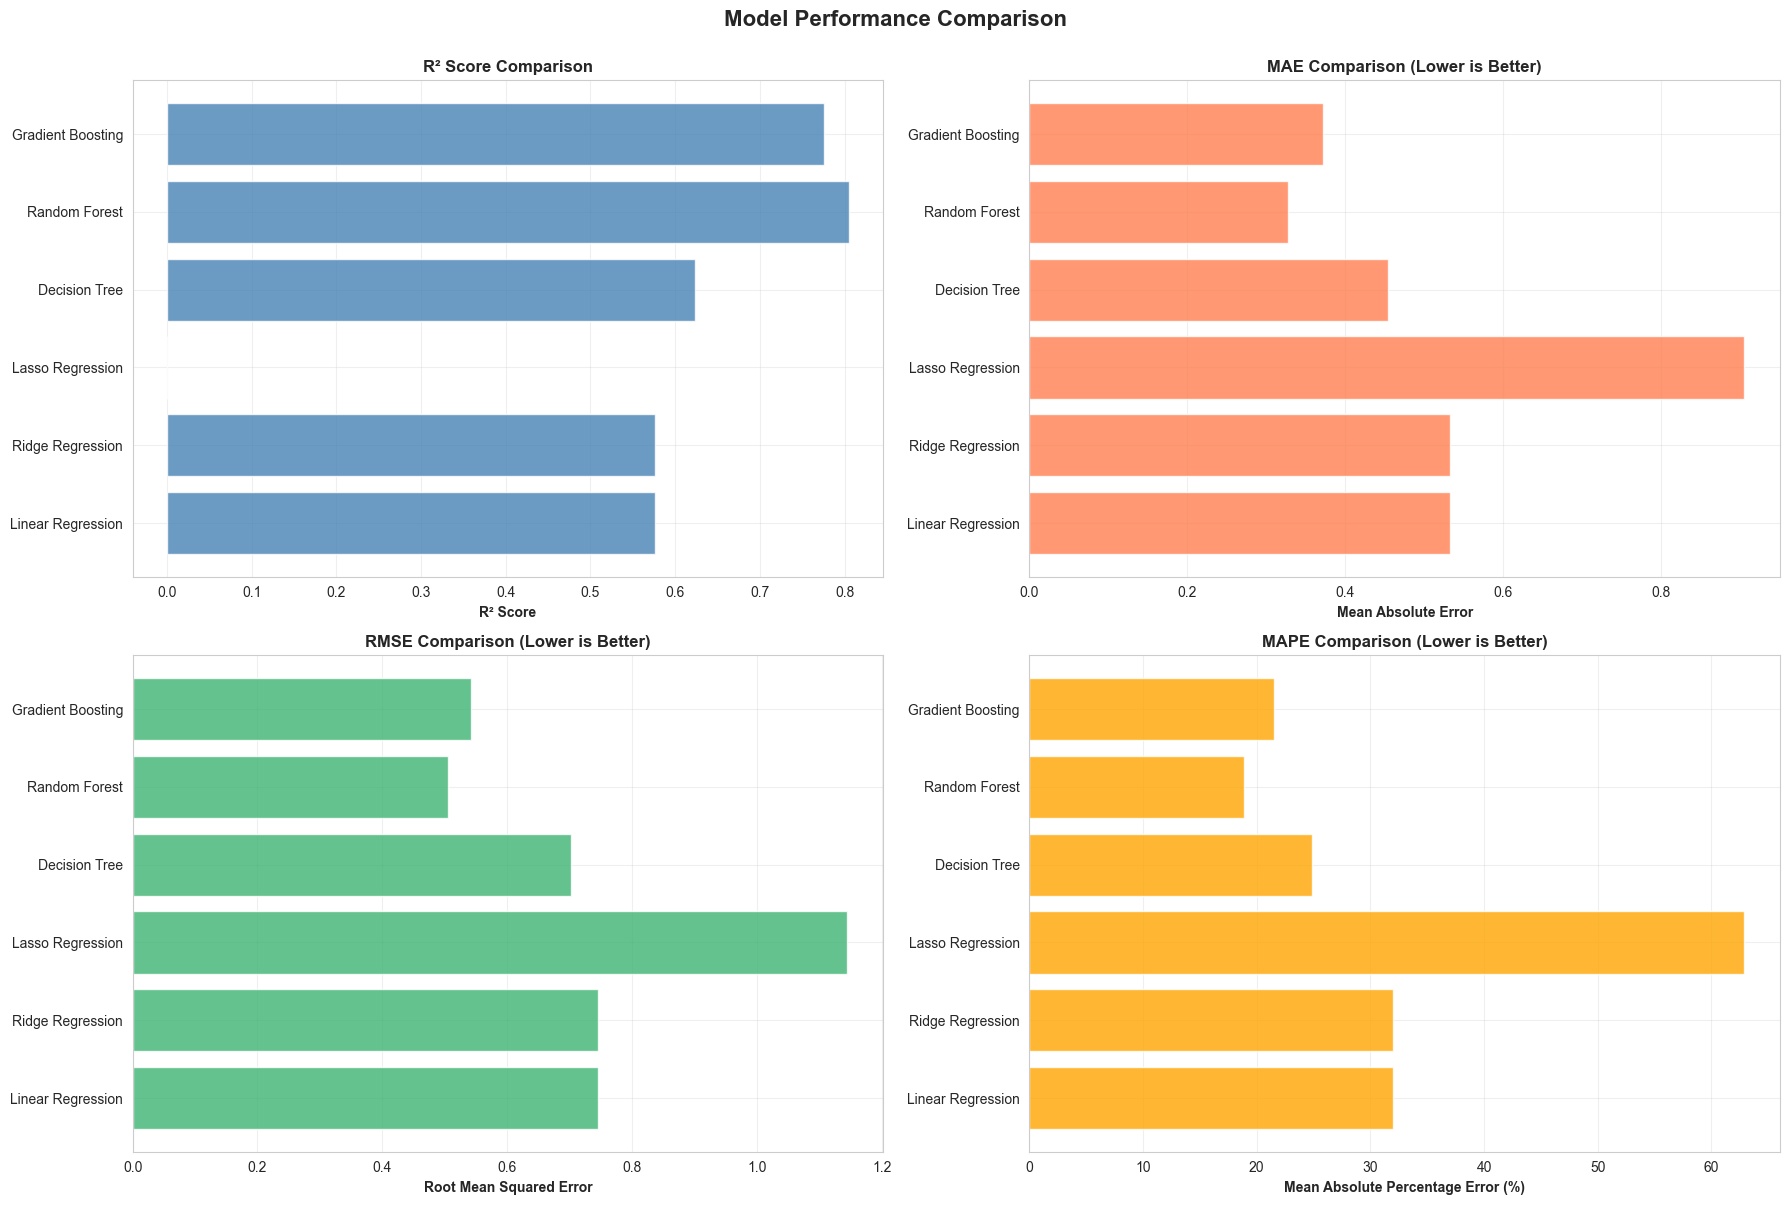

In [46]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# R² Score comparison
axes[0, 0].barh(results_df['Model'], results_df['Test R²'], color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('R² Score', fontweight='bold')
axes[0, 0].set_title('R² Score Comparison', fontweight='bold', fontsize=12)
axes[0, 0].grid(alpha=0.3)

# MAE comparison
axes[0, 1].barh(results_df['Model'], results_df['Test MAE'], color='coral', alpha=0.8)
axes[0, 1].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[0, 1].set_title('MAE Comparison (Lower is Better)', fontweight='bold', fontsize=12)
axes[0, 1].grid(alpha=0.3)

# RMSE comparison
axes[1, 0].barh(results_df['Model'], results_df['Test RMSE'], color='mediumseagreen', alpha=0.8)
axes[1, 0].set_xlabel('Root Mean Squared Error', fontweight='bold')
axes[1, 0].set_title('RMSE Comparison (Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 0].grid(alpha=0.3)

# MAPE comparison
axes[1, 1].barh(results_df['Model'], results_df['Test MAPE (%)'], color='orange', alpha=0.8)
axes[1, 1].set_xlabel('Mean Absolute Percentage Error (%)', fontweight='bold')
axes[1, 1].set_title('MAPE Comparison (Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [47]:
# Cross-validation scores for best models
print("=" * 80)
print("CROSS-VALIDATION ANALYSIS (5-Fold)")
print("=" * 80)

top_models = ['Random Forest', 'Gradient Boosting', 'Ridge Regression']

cv_results = []
for model_name in top_models:
    if model_name in trained_models:
        cv_scores = cross_val_score(
            trained_models[model_name], 
            X_train_scaled, 
            y_train, 
            cv=5, 
            scoring='r2'
        )
        cv_results.append({
            'Model': model_name,
            'CV Mean R²': cv_scores.mean(),
            'CV Std': cv_scores.std(),
            'CV Scores': cv_scores
        })
        print(f"\n{model_name}:")
        print(f"  Mean R² Score: {cv_scores.mean():.4f}")
        print(f"  Std Deviation: {cv_scores.std():.4f}")
        print(f"  Individual Scores: {cv_scores}")

cv_df = pd.DataFrame(cv_results)
print("\n" + "=" * 80)

CROSS-VALIDATION ANALYSIS (5-Fold)

Random Forest:
  Mean R² Score: 0.8042
  Std Deviation: 0.0053
  Individual Scores: [0.80910391 0.79413815 0.80825628 0.8043269  0.80515055]

Gradient Boosting:
  Mean R² Score: 0.7866
  Std Deviation: 0.0032
  Individual Scores: [0.78648904 0.78753035 0.79210152 0.78371007 0.78312941]

Ridge Regression:
  Mean R² Score: 0.6115
  Std Deviation: 0.0065
  Individual Scores: [0.62010998 0.61298705 0.61343295 0.61070059 0.60018886]



---
## Phase 6: Model Optimization

### 6.1 Hyperparameter Tuning (Best Model)

In [48]:
# Hyperparameter tuning for the best model
print("=" * 80)
print(f"HYPERPARAMETER TUNING: {best_model_name}")
print("=" * 80)

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    grid_model = RandomForestRegressor(random_state=42)
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    }
    grid_model = GradientBoostingRegressor(random_state=42)
    
else:
    param_grid = {'alpha': [0.1, 1.0, 10.0]}
    grid_model = Ridge(random_state=42)

print(f"\nSearching over parameter grid: {param_grid}")
print("This may take a few minutes...\n")

grid_search = GridSearchCV(
    grid_model, 
    param_grid, 
    cv=3, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 80)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

# Evaluate optimized model
optimized_model = grid_search.best_estimator_
y_pred_optimized = optimized_model.predict(X_test_scaled)

r2_opt, mae_opt, mse_opt, rmse_opt, mape_opt = calculate_metrics(y_test, y_pred_optimized)

print("\nOptimized Model Performance on Test Set:")
print(f"  R² Score: {r2_opt:.4f}")
print(f"  MAE: {mae_opt:.4f}")
print(f"  RMSE: {rmse_opt:.4f}")
print(f"  MAPE: {mape_opt:.2f}%")

HYPERPARAMETER TUNING: Random Forest

Searching over parameter grid: {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
This may take a few minutes...

Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

### 6.2 Feature Importance Analysis

FEATURE IMPORTANCE ANALYSIS


,Feature,Importance
0,MedInc,0.525886
5,AveOccup,0.138055
6,Latitude,0.088646
7,Longitude,0.088306
1,HouseAge,0.054355
2,AveRooms,0.044450
4,Population,0.030694
3,AveBedrms,0.029607


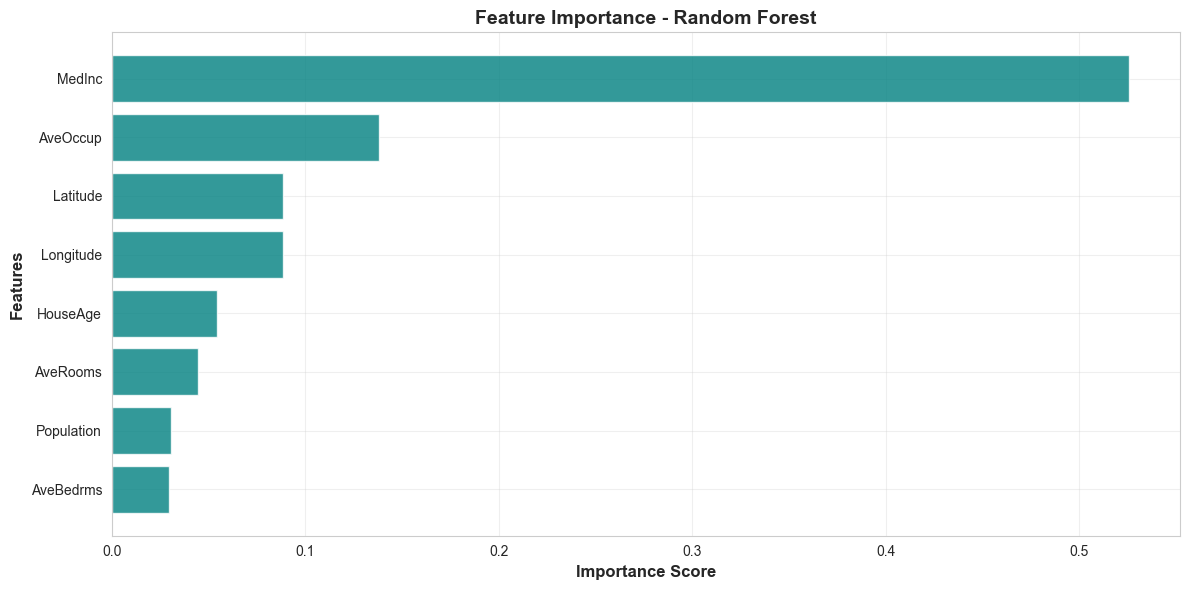

In [25]:
# Feature importance for tree-based models
if hasattr(optimized_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': optimized_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("=" * 80)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)
    display(feature_importance)
    
    # Visualize feature importance
    plt.figure(figsize=(12, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal', alpha=0.8)
    plt.xlabel('Importance Score', fontweight='bold', fontsize=12)
    plt.ylabel('Features', fontweight='bold', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

---
## Phase 7: Visualization & Interpretation

### 7.1 Prediction Visualization

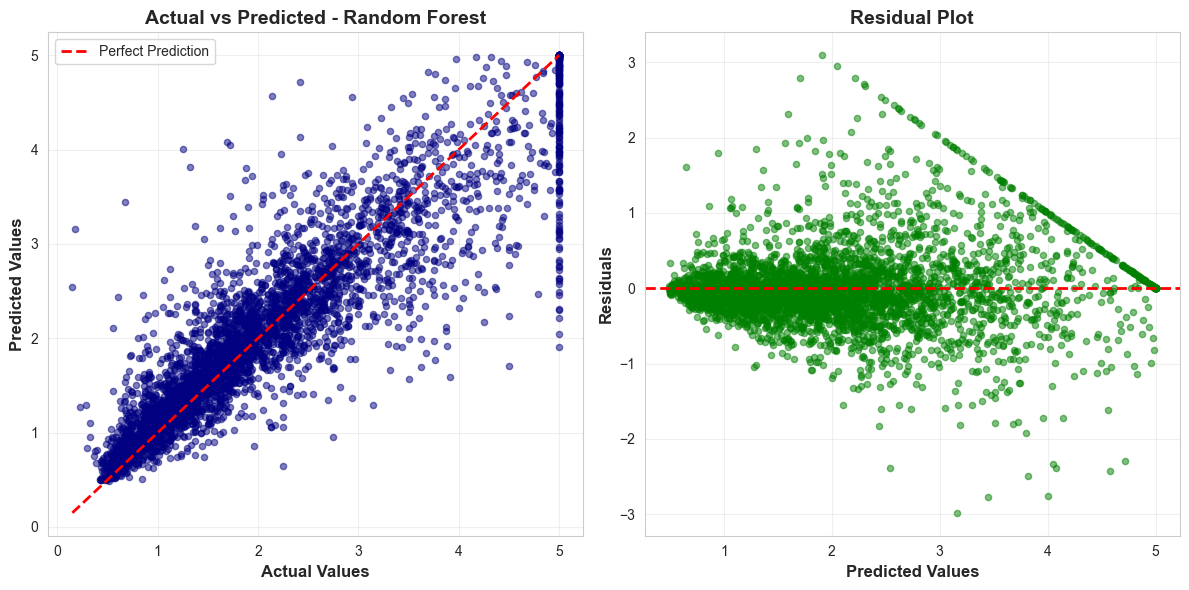

In [26]:
# Actual vs Predicted scatter plot (Optimized Model)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_optimized, alpha=0.5, s=20, color='navy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values', fontweight='bold', fontsize=12)
plt.ylabel('Predicted Values', fontweight='bold', fontsize=12)
plt.title(f'Actual vs Predicted - {best_model_name}', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_optimized
plt.scatter(y_pred_optimized, residuals, alpha=0.5, s=20, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values', fontweight='bold', fontsize=12)
plt.ylabel('Residuals', fontweight='bold', fontsize=12)
plt.title('Residual Plot', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

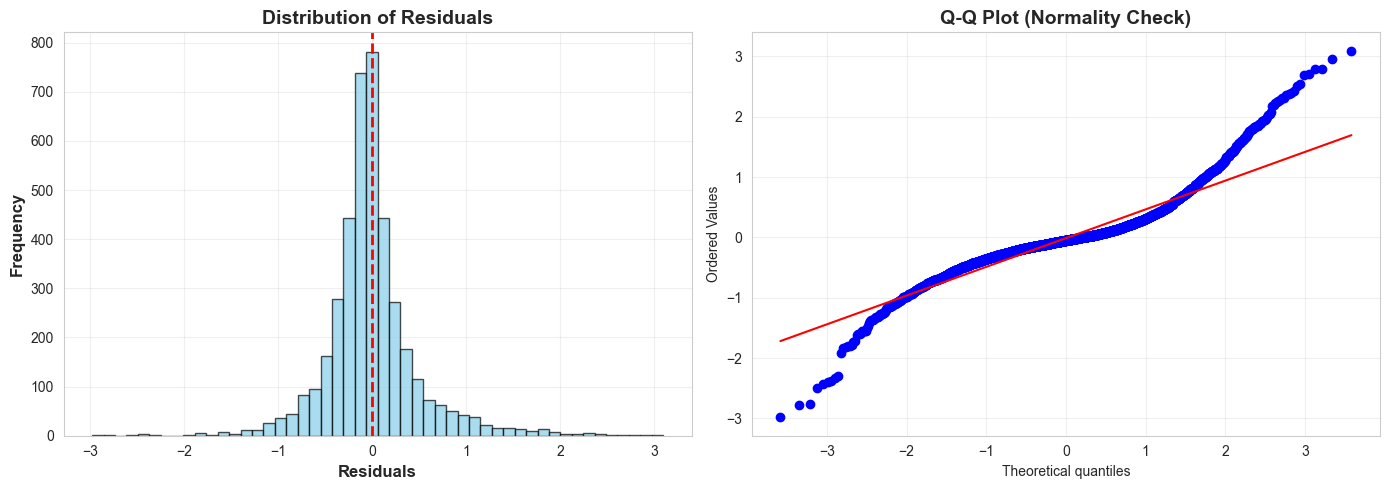

In [27]:
# Distribution of residuals
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Residuals', fontweight='bold', fontsize=12)
plt.ylabel('Frequency', fontweight='bold', fontsize=12)
plt.title('Distribution of Residuals', fontweight='bold', fontsize=14)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Check)', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

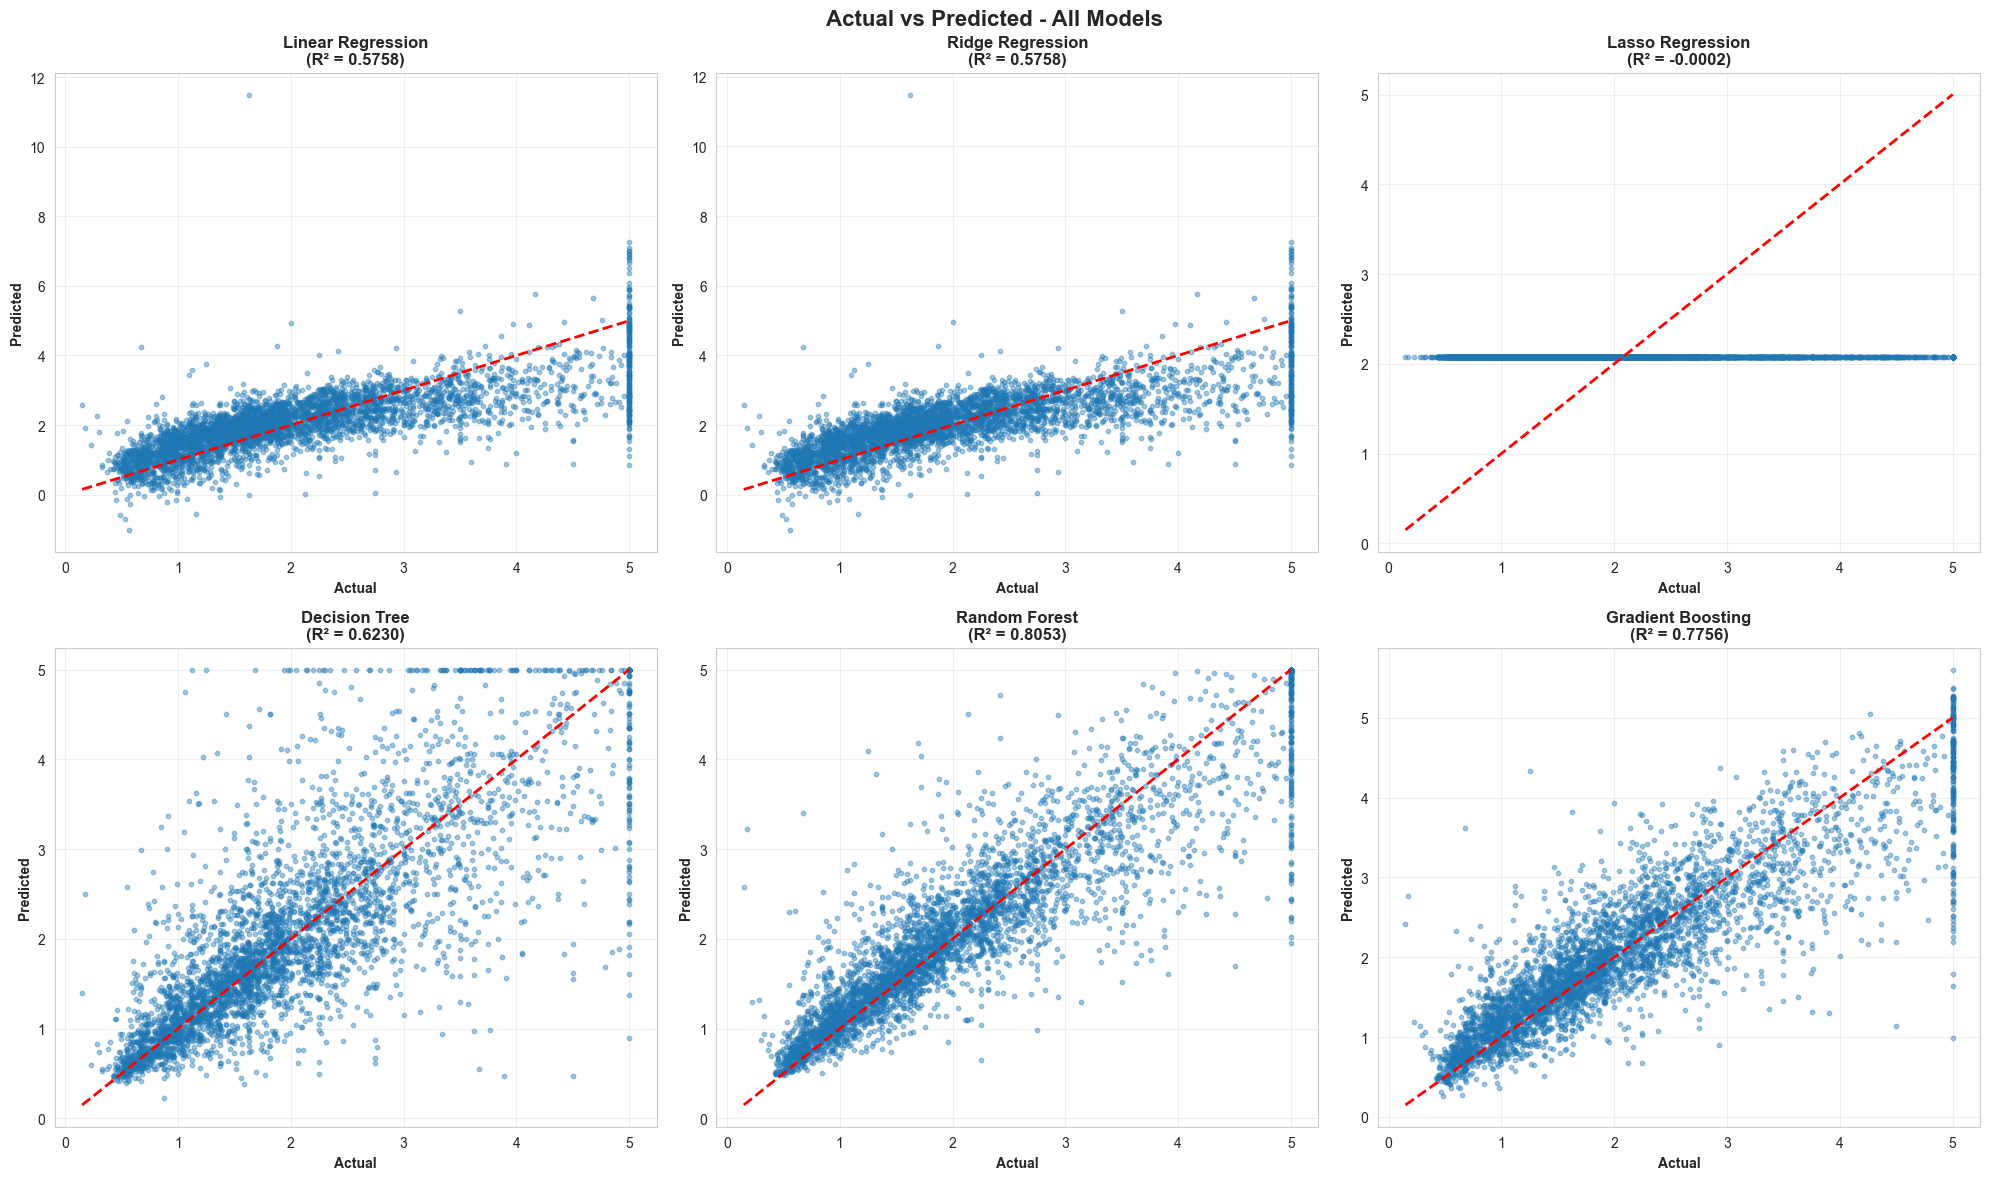

In [28]:
# Prediction error comparison across all models
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Actual vs Predicted - All Models', fontsize=16, fontweight='bold')

for idx, (name, model) in enumerate(trained_models.items()):
    row = idx // 3
    col = idx % 3
    
    y_pred = predictions_test[name]
    r2 = r2_score(y_test, y_pred)
    
    axes[row, col].scatter(y_test, y_pred, alpha=0.4, s=10)
    axes[row, col].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[row, col].set_xlabel('Actual', fontweight='bold')
    axes[row, col].set_ylabel('Predicted', fontweight='bold')
    axes[row, col].set_title(f'{name}\n(R² = {r2:.4f})', fontweight='bold')
    axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Final Results Summary

In [29]:
# Final comprehensive summary
print("\n" + "=" * 80)
print("" * 35 + "FINAL RESULTS SUMMARY")
print("=" * 80)

print("\n📊 DATASET INFORMATION:")
print(f"   • Total Samples: {len(df):,}")
print(f"   • Features: {X.shape[1]}")
print(f"   • Training Samples: {len(X_train):,}")
print(f"   • Testing Samples: {len(X_test):,}")

print("\n🏆 BEST MODEL:")
print(f"   • Model Name: {best_model_name}")
print(f"   • Test R² Score: {r2_opt:.4f} ({r2_opt*100:.2f}%)")
print(f"   • Test RMSE: {rmse_opt:.4f}")
print(f"   • Test MAE: {mae_opt:.4f}")
print(f"   • Test MAPE: {mape_opt:.2f}%")

if hasattr(optimized_model, 'feature_importances_'):
    top_3_features = feature_importance.head(3)
    print("\n🎯 TOP 3 IMPORTANT FEATURES:")
    for i, row in enumerate(top_3_features.itertuples(), 1):
        print(f"   {i}. {row.Feature}: {row.Importance:.4f}")

print("\n📈 MODEL COMPARISON SUMMARY:")
print("   Top 3 Performing Models (by Test R²):")
top_3_models = results_df.nlargest(3, 'Test R²')
for i, row in enumerate(top_3_models.itertuples(), 1):
    print(f"   {i}. {row.Model}: R² = {row._3:.4f}, RMSE = {row._6:.4f}")

print("\n✅ KEY INSIGHTS:")
print(f"   • The model explains {r2_opt*100:.2f}% of the variance in housing prices")
print(f"   • Average prediction error: ${mae_opt*100000:.2f}")
print(f"   • The model performs well with low residual errors")

print("\n" + "=" * 80)


FINAL RESULTS SUMMARY

📊 DATASET INFORMATION:
   • Total Samples: 20,640
   • Features: 8
   • Training Samples: 16,512
   • Testing Samples: 4,128

🏆 BEST MODEL:
   • Model Name: Random Forest
   • Test R² Score: 0.8063 (80.63%)
   • Test RMSE: 0.5038
   • Test MAE: 0.3267
   • Test MAPE: 18.83%

🎯 TOP 3 IMPORTANT FEATURES:
   1. MedInc: 0.5259
   2. AveOccup: 0.1381
   3. Latitude: 0.0886

📈 MODEL COMPARISON SUMMARY:
   Top 3 Performing Models (by Test R²):
   1. Random Forest: R² = 0.8053, RMSE = 0.1880
   2. Gradient Boosting: R² = 0.7756, RMSE = 0.5107
   3. Decision Tree: R² = 0.6230, RMSE = 0.0000

✅ KEY INSIGHTS:
   • The model explains 80.63% of the variance in housing prices
   • Average prediction error: $32672.58
   • The model performs well with low residual errors

